# Production RAG — Модуль 1: Chunking

## Зачем отдельный модуль про chunking?

В `09_rag_project` мы использовали `RecursiveCharacterTextSplitter` с дефолтными параметрами.  
В продакшене **качество chunks = качество RAG**. Плохая разбивка → мусор в контексте → галлюцинации.

### Что изучим:
1. Как выбрать `chunk_size` и `chunk_overlap`
2. Стратегии: character, recursive, semantic, document-aware
3. Parent-child chunks (маленькие для поиска, большие для контекста)
4. Сравнение стратегий на реальных данных

### Java аналогия:

```java
// Chunking — это как индексация в Lucene/Elasticsearch
// Плохой tokenizer → плохой поиск
// Плохой chunking → плохой RAG

// Наивный подход:
List<String> chunks = text.split("\\n"); // Ломает предложения

// Production подход:
List<Chunk> chunks = new SemanticChunker(embeddingModel)
    .withMaxSize(512)
    .withOverlap(50)
    .split(document);
```

In [ ]:
# Пакеты уже установлены в venv lc-academy-env:
# pip install langchain langchain-text-splitters langchain-experimental langchain-community sentence-transformers matplotlib numpy
print("Пакеты загружены из venv")

In [2]:
# Тестовый документ — реалистичный текст про Spring Boot
SAMPLE_DOC = """Spring Boot Actuator — модуль для мониторинга и управления приложением в production.

## Основные эндпоинты

Actuator предоставляет HTTP-эндпоинты для проверки состояния приложения:

- `/actuator/health` — проверка здоровья. Возвращает UP или DOWN.
  Поддерживает кастомные HealthIndicator для проверки БД, Kafka, внешних сервисов.
- `/actuator/metrics` — метрики JVM, HTTP запросов, кастомные счётчики.
  Интегрируется с Prometheus через Micrometer.
- `/actuator/info` — информация о приложении: версия, git commit, build time.
- `/actuator/env` — текущие переменные окружения и конфигурация.

## Безопасность

По умолчанию только `/health` доступен без авторизации.
Остальные эндпоинты требуют Spring Security:

```java
@Configuration
public class ActuatorSecurityConfig {
    @Bean
    SecurityFilterChain actuatorSecurity(HttpSecurity http) throws Exception {
        return http
            .requestMatchers(EndpointRequest.toAnyEndpoint())
            .authorizeHttpRequests(auth -> auth
                .requestMatchers("/actuator/health").permitAll()
                .anyRequest().hasRole("ADMIN")
            )
            .build();
    }
}
```

## Кастомные метрики

Для бизнес-метрик используйте Micrometer API:

```java
@Service
public class OrderService {
    private final Counter orderCounter;
    private final Timer orderTimer;

    public OrderService(MeterRegistry registry) {
        this.orderCounter = registry.counter("orders.created");
        this.orderTimer = registry.timer("orders.processing.time");
    }

    public Order createOrder(OrderRequest request) {
        return orderTimer.record(() -> {
            Order order = processOrder(request);
            orderCounter.increment();
            return order;
        });
    }
}
```

## Интеграция с Kubernetes

Spring Boot Actuator идеально подходит для K8s probes:

- `livenessProbe` → `/actuator/health/liveness` — приложение живо?
- `readinessProbe` → `/actuator/health/readiness` — готово принимать трафик?

Включение в application.yml:
```yaml
management:
  endpoint:
    health:
      probes:
        enabled: true
  health:
    livenessstate:
      enabled: true
    readinessstate:
      enabled: true
```
"""

print(f"Длина документа: {len(SAMPLE_DOC)} символов")
print(f"Строк: {len(SAMPLE_DOC.splitlines())}")

Длина документа: 2198 символов
Строк: 79


---
## 1. CharacterTextSplitter — наивный подход

Разбивает строго по количеству символов. Может разорвать слово или предложение на полуслове.

```java
// Аналог: substring с фиксированным шагом
for (int i = 0; i < text.length(); i += chunkSize) {
    chunks.add(text.substring(i, Math.min(i + chunkSize, text.length())));
}
// Проблема: разрежет "Spring Boot" на "Spri" и "ng Boot"
```

In [3]:
from langchain_text_splitters import CharacterTextSplitter

naive_splitter = CharacterTextSplitter(
    separator="",       # Без разделителя — режем по символам
    chunk_size=200,
    chunk_overlap=0
)

naive_chunks = naive_splitter.split_text(SAMPLE_DOC)

print(f"Chunks: {len(naive_chunks)}\n")
for i, chunk in enumerate(naive_chunks[:3]):
    print(f"--- Chunk {i+1} ({len(chunk)} символов) ---")
    print(chunk)
    print()

C:\Users\Ruslan\ai-learning\langchain-academy\lc-academy-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chunks: 11

--- Chunk 1 (200 символов) ---
Spring Boot Actuator — модуль для мониторинга и управления приложением в production.

## Основные эндпоинты

Actuator предоставляет HTTP-эндпоинты для проверки состояния приложения:

- `/actuator/heal

--- Chunk 2 (200 символов) ---
th` — проверка здоровья. Возвращает UP или DOWN.
  Поддерживает кастомные HealthIndicator для проверки БД, Kafka, внешних сервисов.
- `/actuator/metrics` — метрики JVM, HTTP запросов, кастомные счётчи

--- Chunk 3 (200 символов) ---
ки.
  Интегрируется с Prometheus через Micrometer.
- `/actuator/info` — информация о приложении: версия, git commit, build time.
- `/actuator/env` — текущие переменные окружения и конфигурация.

## Бе



Видишь проблему? Chunks обрезаются посреди слов и код-блоков. Для поиска это мусор.

---
## 2. RecursiveCharacterTextSplitter — стандарт

Пробует разделители **по приоритету**: `\n\n` → `\n` → `.` → ` ` → символ.  
Так chunk заканчивается на границе абзаца, предложения или хотя бы слова.

```java
// Аналог: "умный" splitter с fallback
List<String> separators = List.of("\n\n", "\n", ". ", " ");
for (String sep : separators) {
    if (text.contains(sep) && canSplitWithin(text, sep, maxSize)) {
        return splitBy(text, sep);
    }
}
// Fallback: режем по символам
```

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " "]
)

recursive_chunks = recursive_splitter.split_text(SAMPLE_DOC)

print(f"Chunks: {len(recursive_chunks)}\n")
for i, chunk in enumerate(recursive_chunks[:4]):
    print(f"--- Chunk {i+1} ({len(chunk)} символов) ---")
    print(chunk)
    print()

Chunks: 11

--- Chunk 1 (181 символов) ---
Spring Boot Actuator — модуль для мониторинга и управления приложением в production.

## Основные эндпоинты

Actuator предоставляет HTTP-эндпоинты для проверки состояния приложения:

--- Chunk 2 (267 символов) ---
- `/actuator/health` — проверка здоровья. Возвращает UP или DOWN.
  Поддерживает кастомные HealthIndicator для проверки БД, Kafka, внешних сервисов.
- `/actuator/metrics` — метрики JVM, HTTP запросов, кастомные счётчики.
  Интегрируется с Prometheus через Micrometer.

--- Chunk 3 (187 символов) ---
Интегрируется с Prometheus через Micrometer.
- `/actuator/info` — информация о приложении: версия, git commit, build time.
- `/actuator/env` — текущие переменные окружения и конфигурация.

--- Chunk 4 (117 символов) ---
## Безопасность

По умолчанию только `/health` доступен без авторизации.
Остальные эндпоинты требуют Spring Security:



Уже лучше — chunks на границах абзацев. Но всё ещё не учитывает **смысл** текста.

---
## 3. Выбор chunk_size и chunk_overlap

Главный вопрос: **какой размер chunk оптимален?**

| Параметр | Маленький (100-200) | Средний (300-500) | Большой (800-1500) |
|----------|-------------------|-------------------|--------------------|
| Точность поиска | Высокая | Средняя | Низкая |
| Контекст в chunk | Мало | Достаточно | Много |
| Кол-во chunks | Много | Средне | Мало |
| Стоимость embedding | Высокая | Средняя | Низкая |
| Лучше для | FAQ, определения | Документация | Длинные статьи |

**Правило:** `chunk_overlap` = 10-20% от `chunk_size`.

```java
// Аналогия: размер страницы в пагинации
// pageSize=10 → точный, но много запросов
// pageSize=100 → один запрос, но много мусора
Pageable page = PageRequest.of(0, optimalSize);
```

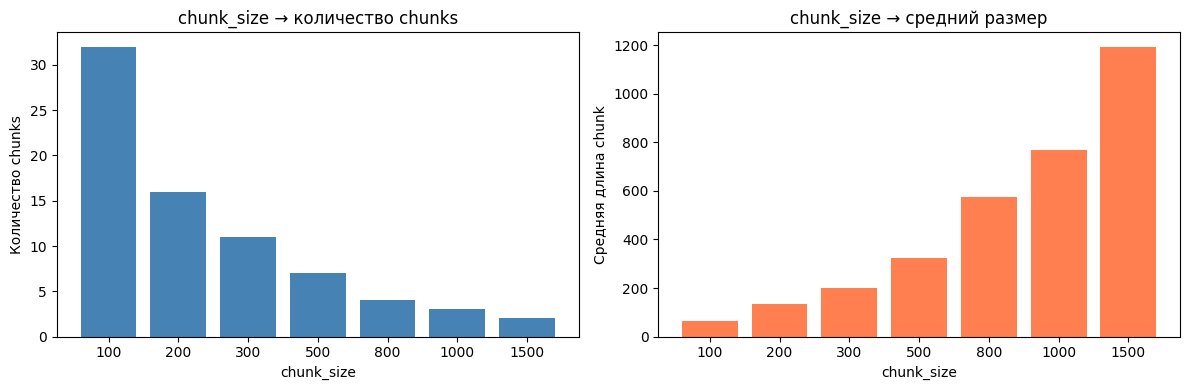

In [5]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Визуализация: как chunk_size влияет на количество и размер chunks
sizes = [100, 200, 300, 500, 800, 1000, 1500]
counts = []
avg_lens = []

for size in sizes:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=int(size * 0.15)
    )
    chunks = splitter.split_text(SAMPLE_DOC)
    counts.append(len(chunks))
    avg_lens.append(np.mean([len(c) for c in chunks]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(len(sizes)), counts, color='steelblue')
ax1.set_xticks(range(len(sizes)))
ax1.set_xticklabels(sizes)
ax1.set_xlabel('chunk_size')
ax1.set_ylabel('Количество chunks')
ax1.set_title('chunk_size → количество chunks')

ax2.bar(range(len(sizes)), avg_lens, color='coral')
ax2.set_xticks(range(len(sizes)))
ax2.set_xticklabels(sizes)
ax2.set_xlabel('chunk_size')
ax2.set_ylabel('Средняя длина chunk')
ax2.set_title('chunk_size → средний размер')

plt.tight_layout()
plt.show()

---
## 4. Document-aware splitting

Для Markdown, Python, Java, HTML — есть **специализированные splitter'ы** которые знают структуру формата.

```java
// Аналогия: парсер знает грамматику языка
// Generic splitter — как String.split()
// Markdown splitter — как JSoup для HTML
```

In [6]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

# Markdown splitter — разбивает по заголовкам и сохраняет иерархию в metadata
md_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "h1"),
        ("##", "h2"),
        ("###", "h3"),
    ]
)

md_chunks = md_splitter.split_text(SAMPLE_DOC)

print(f"Markdown chunks: {len(md_chunks)}\n")
for i, chunk in enumerate(md_chunks):
    print(f"--- Chunk {i+1} ---")
    print(f"Metadata: {chunk.metadata}")
    print(f"Content: {chunk.page_content[:150]}...")
    print()

Markdown chunks: 5

--- Chunk 1 ---
Metadata: {}
Content: Spring Boot Actuator — модуль для мониторинга и управления приложением в production....

--- Chunk 2 ---
Metadata: {'h2': 'Основные эндпоинты'}
Content: Actuator предоставляет HTTP-эндпоинты для проверки состояния приложения:  
- `/actuator/health` — проверка здоровья. Возвращает UP или DOWN.
Поддержив...

--- Chunk 3 ---
Metadata: {'h2': 'Безопасность'}
Content: По умолчанию только `/health` доступен без авторизации.
Остальные эндпоинты требуют Spring Security:  
```java
@Configuration
public class ActuatorSec...

--- Chunk 4 ---
Metadata: {'h2': 'Кастомные метрики'}
Content: Для бизнес-метрик используйте Micrometer API:  
```java
@Service
public class OrderService {
private final Counter orderCounter;
private final Timer o...

--- Chunk 5 ---
Metadata: {'h2': 'Интеграция с Kubernetes'}
Content: Spring Boot Actuator идеально подходит для K8s probes:  
- `livenessProbe` → `/actuator/health/liveness` — приложение живо?
- `readine

In [7]:
from langchain_text_splitters import Language, RecursiveCharacterTextSplitter

# Java-aware splitter — знает про классы, методы, блоки
java_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.JAVA,
    chunk_size=500,
    chunk_overlap=50
)

java_code = """
@Service
public class UserService {
    private final UserRepository userRepo;
    private final PasswordEncoder encoder;

    public UserService(UserRepository userRepo, PasswordEncoder encoder) {
        this.userRepo = userRepo;
        this.encoder = encoder;
    }

    public User createUser(CreateUserRequest request) {
        if (userRepo.existsByEmail(request.getEmail())) {
            throw new DuplicateEmailException(request.getEmail());
        }
        User user = new User();
        user.setEmail(request.getEmail());
        user.setPassword(encoder.encode(request.getPassword()));
        user.setRole(Role.USER);
        return userRepo.save(user);
    }

    public Optional<User> findByEmail(String email) {
        return userRepo.findByEmail(email);
    }

    @Transactional
    public void deactivateUser(Long userId) {
        User user = userRepo.findById(userId)
            .orElseThrow(() -> new UserNotFoundException(userId));
        user.setActive(false);
        userRepo.save(user);
    }
}
"""

java_chunks = java_splitter.split_text(java_code)

print(f"Java chunks: {len(java_chunks)}\n")
for i, chunk in enumerate(java_chunks):
    print(f"--- Chunk {i+1} ({len(chunk)} символов) ---")
    print(chunk)
    print()

Java chunks: 4

--- Chunk 1 (8 символов) ---
@Service

--- Chunk 2 (260 символов) ---
public class UserService {
    private final UserRepository userRepo;
    private final PasswordEncoder encoder;

    public UserService(UserRepository userRepo, PasswordEncoder encoder) {
        this.userRepo = userRepo;
        this.encoder = encoder;
    }

--- Chunk 3 (401 символов) ---
public User createUser(CreateUserRequest request) {
        if (userRepo.existsByEmail(request.getEmail())) {
            throw new DuplicateEmailException(request.getEmail());
        }
        User user = new User();
        user.setEmail(request.getEmail());
        user.setPassword(encoder.encode(request.getPassword()));
        user.setRole(Role.USER);
        return userRepo.save(user);
    }

--- Chunk 4 (346 символов) ---
public Optional<User> findByEmail(String email) {
        return userRepo.findByEmail(email);
    }

    @Transactional
    public void deactivateUser(Long userId) {
        User user = u

Java splitter разделил по методам, а не посреди кода — это критически важно для RAG по кодовой базе.

---
## 5. Semantic Chunking

**Самый продвинутый подход:** разбивка по смыслу, а не по символам.  
Использует embeddings чтобы найти, где **меняется тема**.

```
Предложение 1 ─┐
Предложение 2 ─┤ similarity > threshold → один chunk
Предложение 3 ─┘
                  ← breakpoint (тема изменилась)
Предложение 4 ─┐
Предложение 5 ─┤ similarity > threshold → другой chunk
Предложение 6 ─┘
```

```java
// Аналогия: вместо split по символам — кластеризация по смыслу
// Как группировка товаров по категориям вместо нарезки по ID
```

In [8]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_community.embeddings import HuggingFaceEmbeddings

# Загружаем embedding модель для semantic chunking
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'}
)

semantic_splitter = SemanticChunker(
    embeddings=embeddings,
    breakpoint_threshold_type="percentile",  # Порог: percentile, standard_deviation, interquartile
    breakpoint_threshold_amount=70  # 70-й перцентиль разницы → breakpoint
)

semantic_chunks = semantic_splitter.split_text(SAMPLE_DOC)

print(f"Semantic chunks: {len(semantic_chunks)}\n")
for i, chunk in enumerate(semantic_chunks):
    print(f"--- Chunk {i+1} ({len(chunk)} символов) ---")
    print(chunk[:200])
    if len(chunk) > 200:
        print("...")
    print()

C:\Users\Ruslan\AppData\Local\Temp\ipykernel_1112\2110509733.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


C:\Users\Ruslan\ai-learning\langchain-academy\lc-academy-env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ruslan\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Semantic chunks: 4

--- Chunk 1 (223 символов) ---
Spring Boot Actuator — модуль для мониторинга и управления приложением в production. ## Основные эндпоинты

Actuator предоставляет HTTP-эндпоинты для проверки состояния приложения:

- `/actuator/healt
...

--- Chunk 2 (364 символов) ---
Возвращает UP или DOWN. Поддерживает кастомные HealthIndicator для проверки БД, Kafka, внешних сервисов. - `/actuator/metrics` — метрики JVM, HTTP запросов, кастомные счётчики. Интегрируется с Prometh
...

--- Chunk 3 (1399 символов) ---
## Безопасность

По умолчанию только `/health` доступен без авторизации. Остальные эндпоинты требуют Spring Security:

```java
@Configuration
public class ActuatorSecurityConfig {
    @Bean
    Securi
...

--- Chunk 4 (202 символов) ---
Включение в application.yml:
```yaml
management:
  endpoint:
    health:
      probes:
        enabled: true
  health:
    livenessstate:
      enabled: true
    readinessstate:
      enabled: true
``
...



---
## 6. Parent-Child Chunks

Ключевой production-паттерн:
- **Child chunks** (маленькие, ~200 символов) → для точного **поиска**
- **Parent chunks** (большие, ~1000 символов) → для полного **контекста** в промпт

```
┌──────────── Parent chunk (1000 символов) ────────────┐
│                                                       │
│  ┌─ Child 1 ─┐  ┌─ Child 2 ─┐  ┌─ Child 3 ─┐       │
│  │  200 сим.  │  │  200 сим.  │  │  200 сим.  │       │
│  └────────────┘  └────────────┘  └────────────┘       │
│                       ↑                               │
│                 Найден поиском                        │
└───────────────────────┬───────────────────────────────┘
                        ↓
              В LLM отправляем Parent
```

```java
// Аналогия: индекс vs полная запись
// 1. Ищем по индексу (child) — быстро и точно
// 2. Достаём полную запись (parent) — для контекста

// Как в JPA:
@Entity
class DocumentIndex { // child — для поиска
    @Id Long id;
    String snippet;  // 200 символов
    @ManyToOne Document parent;
}

@Entity
class Document { // parent — для контекста
    @Id Long id;
    @Lob String fullContent; // 1000 символов
}
```

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Parent splitter — большие chunks
parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

# Child splitter — маленькие chunks
child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=30
)

parent_chunks = parent_splitter.split_text(SAMPLE_DOC)

# Для каждого parent создаём children с ссылкой на parent
parent_child_map = []
for parent_idx, parent_text in enumerate(parent_chunks):
    children = child_splitter.split_text(parent_text)
    for child_text in children:
        parent_child_map.append({
            "child": child_text,
            "parent_idx": parent_idx,
            "parent": parent_text
        })

print(f"Parents: {len(parent_chunks)}")
print(f"Children: {len(parent_child_map)}")
print(f"\n--- Пример child ---")
print(f"Child: {parent_child_map[2]['child'][:100]}...")
print(f"Parent idx: {parent_child_map[2]['parent_idx']}")
print(f"Parent size: {len(parent_child_map[2]['parent'])} символов")

Parents: 3
Children: 16

--- Пример child ---
Child: - `/actuator/metrics` — метрики JVM, HTTP запросов, кастомные счётчики.
  Интегрируется с Prometheus...
Parent idx: 0
Parent size: 712 символов


In [10]:
# В LangChain есть готовый ParentDocumentRetriever
# Но принцип тот же: ищем по child, возвращаем parent

def search_parent_child(query: str, child_chunks: list, top_k: int = 2):
    """Простая демо-версия parent-child retrieval"""
    # В продакшене здесь vector search по child embeddings
    # Для демо — keyword search
    query_words = set(query.lower().split())
    
    scored = []
    for item in child_chunks:
        child_words = set(item['child'].lower().split())
        score = len(query_words & child_words)
        scored.append((score, item))
    
    scored.sort(key=lambda x: x[0], reverse=True)
    
    # Дедупликация по parent_idx
    seen_parents = set()
    results = []
    for score, item in scored:
        if item['parent_idx'] not in seen_parents and score > 0:
            seen_parents.add(item['parent_idx'])
            results.append(item)
            if len(results) >= top_k:
                break
    return results

# Тест
query = "Kubernetes probes health check"
results = search_parent_child(query, parent_child_map)

print(f"Запрос: {query}\n")
for r in results:
    print(f"Найден child: {r['child'][:80]}...")
    print(f"Возвращаем parent ({len(r['parent'])} символов): {r['parent'][:150]}...")
    print()

Запрос: Kubernetes probes health check

Найден child: ## Интеграция с Kubernetes

Spring Boot Actuator идеально подходит для K8s probe...
Возвращаем parent (658 символов): public Order createOrder(OrderRequest request) {
        return orderTimer.record(() -> {
            Order order = processOrder(request);
           ...



---
## 7. Сравнение стратегий

| Стратегия | Когда использовать | Плюсы | Минусы |
|-----------|-------------------|-------|--------|
| **Character** | Никогда в production | Простой | Ломает слова и смысл |
| **Recursive** | По умолчанию | Хороший баланс | Не учитывает семантику |
| **Markdown/Code** | Документация, код | Учитывает структуру | Только для своего формата |
| **Semantic** | Длинные тексты | Разбивка по смыслу | Медленный (нужны embeddings) |
| **Parent-Child** | Production RAG | Точный поиск + полный контекст | Сложнее в реализации |

### Рекомендация для LegalBPM:

```
Юридические документы → MarkdownHeaderTextSplitter (по разделам)
                       + RecursiveCharacterTextSplitter (внутри разделов)
                       + Parent-Child (точность + контекст)
```

In [11]:
# Финальное сравнение всех стратегий на одном документе

strategies = {
    "Character (200)": CharacterTextSplitter(separator="", chunk_size=200, chunk_overlap=0),
    "Recursive (300)": RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50),
    "Recursive (500)": RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=75),
}

print(f"{'Стратегия':<20} {'Chunks':>8} {'Avg len':>10} {'Min len':>10} {'Max len':>10}")
print("-" * 62)

for name, splitter in strategies.items():
    chunks = splitter.split_text(SAMPLE_DOC)
    lengths = [len(c) for c in chunks]
    print(f"{name:<20} {len(chunks):>8} {np.mean(lengths):>10.0f} {min(lengths):>10} {max(lengths):>10}")

# Markdown — другой формат вывода
md_chunks_count = len(md_splitter.split_text(SAMPLE_DOC))
print(f"{'Markdown headers':<20} {md_chunks_count:>8}       (по разделам)")

sem_chunks_count = len(semantic_chunks)
print(f"{'Semantic':<20} {sem_chunks_count:>8}       (по смыслу)")

Стратегия              Chunks    Avg len    Min len    Max len
--------------------------------------------------------------
Character (200)            11        197        190        200
Recursive (300)            11        207        117        279
Recursive (500)             7        325        117        484
Markdown headers            5       (по разделам)
Semantic                    4       (по смыслу)


---
## Итоги

### Что выучили:
- ✅ Наивный vs умный chunking — почему это критично для RAG
- ✅ `chunk_size` и `chunk_overlap` — как подбирать
- ✅ Document-aware splitting — Markdown, Java, Python
- ✅ Semantic chunking — разбивка по смыслу через embeddings
- ✅ Parent-child — production паттерн для точности + контекста

### Production чеклист:
- [ ] Выбрать стратегию под тип документов
- [ ] Подобрать `chunk_size` экспериментально (начать с 300-500)
- [ ] Для гетерогенных данных — комбинировать стратегии
- [ ] Для максимального качества — Parent-Child + Semantic

### Следующий модуль:
**Модуль 2 — Embeddings:** выбор модели, сравнение, fine-tuning, multilingual.